# Titanic Dataset Analysis

## Objective

The purpose of this project is to analyze the Titanic Dataset using Python.

The analysis includes:

- Loading the dataset
- Exploring and cleaning the data
- Analyzing survival patterns
- Creating visualizations
- Drawing conclusions from the results

The following questions will be answered:

1. Who survived more: males or females?
2. Did passenger class affect survival chances?
3. What was the survival rate by age group?

In [14]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Loading the Dataset

In this section, the Titanic dataset is loaded into a Pandas DataFrame and the first few records are displayed.

In [15]:
df = pd.read_csv("Titanic-Dataset.csv")

print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


## Understanding the Dataset

Before analysis, it is important to understand the dataset structure, columns, and missing values.

In [16]:
print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape:
(891, 12)

Column Names:
Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None

Missing Values:
PassengerId   

## Data Cleaning

The dataset contains missing values in some columns.

Cleaning steps:

- Replace missing Age values using the median age.
- Replace missing Embarked values using the mode.
- Remove the Cabin column because it contains too many missing values.

In [17]:
# Fill Missing Age Values

df["Age"] = df["Age"].fillna(df["Age"].median())

# Fill Missing Embarked Values

df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Drop Cabin Column

df.drop("Cabin", axis=1, inplace=True)

print("Missing Values After Cleaning")

df.isnull().sum()

Missing Values After Cleaning


PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

## Question 1

### Who survived more: Males or Females?

The survival rate of male and female passengers is calculated and compared.

In [18]:
# Survival Rate by Gender

gender_survival = df.groupby("Sex")["Survived"].mean() * 100

print(gender_survival)

Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64


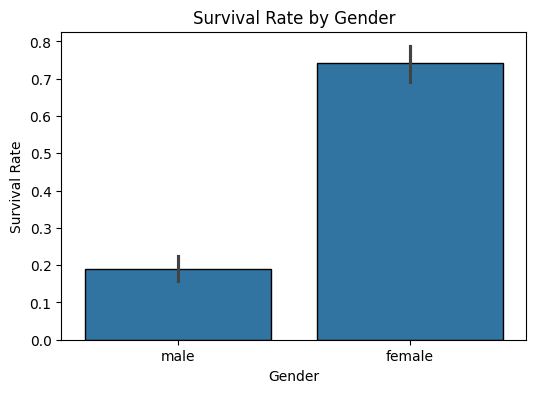

In [19]:
# Visualization: Survival by Gender

plt.figure(figsize=(6,4))

sns.barplot(
    x="Sex",
    y="Survived",
    data=df, edgecolor='black'
)

plt.title("Survival Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Survival Rate")

plt.show()

## Observation

Female passengers had a significantly higher survival rate than male passengers.

## Question 2

### Did Passenger Class Affect Survival Chances?

The survival rate is analyzed across different passenger classes.

In [20]:
# Survival Rate by Passenger Class

class_survival = df.groupby("Pclass")["Survived"].mean() * 100

print(class_survival)

Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64


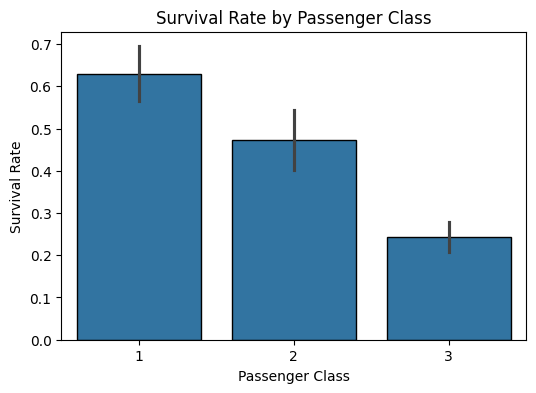

In [21]:
# Visualization: Survival by Passenger Class

plt.figure(figsize=(6,4))

sns.barplot(
    x="Pclass",
    y="Survived",
    data=df, edgecolor='black'
)

plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")

plt.show()

## Observation

Passengers travelling in First Class had the highest survival rate, while Third Class passengers had the lowest survival rate.

## Question 3

### What was the Survival Rate by Age Group?

Passengers are divided into age groups and survival rates are calculated.

In [22]:
# Create Age Groups

bins = [0, 12, 18, 35, 60, 100]

labels = [
    "Child",
    "Teen",
    "Young Adult",
    "Adult",
    "Senior"
]

df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=bins,
    labels=labels
)

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,AgeGroup
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,Young Adult
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,Adult
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,Young Adult
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,Young Adult
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,Young Adult


In [23]:
# Survival Rate by Age Group

age_survival = df.groupby("AgeGroup")["Survived"].mean() * 100

print(age_survival)

AgeGroup
Child          57.971014
Teen           42.857143
Young Adult    35.327103
Adult          40.000000
Senior         22.727273
Name: Survived, dtype: float64


C:\Users\gouri\AppData\Local\Temp\ipykernel_33356\4023056541.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_survival = df.groupby("AgeGroup")["Survived"].mean() * 100


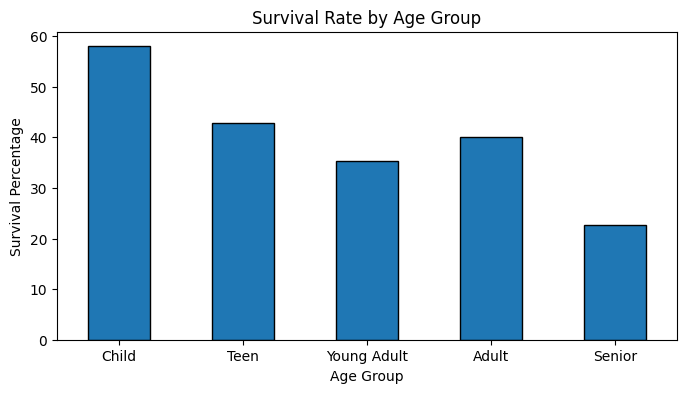

In [24]:
# Visualization: Survival Rate by Age Group

age_survival.plot(
    kind="bar",
    figsize=(8,4), edgecolor='black'
)

plt.title("Survival Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Survival Percentage")

plt.xticks(rotation=0)

plt.show()

## Observation

Children and younger passengers generally showed better survival rates compared to older passengers.

### Histogram of passenger ages.

A histogram is used to visualize the age distribution of passengers.

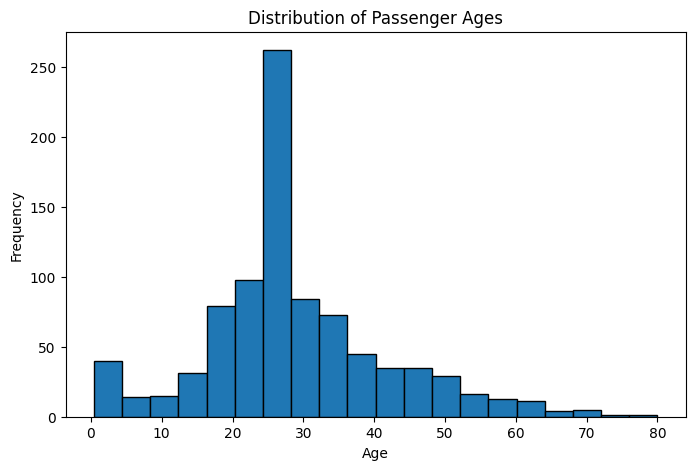

In [25]:


plt.figure(figsize=(8,5))

plt.hist(
    df["Age"],
    bins=20, edgecolor='black'
)

plt.title("Distribution of Passenger Ages")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

## Final Conclusion

The Titanic dataset was analyzed to identify the factors that influenced passenger survival. After cleaning the data and performing exploratory analysis, the following key findings were observed:

1. **Gender had a significant impact on survival.** Female passengers had a survival rate of **74.2%**, which was considerably higher than the survival rate of **18.9%** for male passengers.

2. **Passenger class strongly influenced survival chances.** First-class passengers had the highest survival rate at **62.9%**, while third-class passengers had the lowest survival rate at **24.2%**.

3. **Age also played a role in survival outcomes.** Children generally had better survival rates compared to senior passengers, indicating that younger passengers had a greater chance of survival.

4. **Young adults formed the largest age group** among the passengers on board the Titanic.

5. Based on the analysis, **gender and passenger class were the most influential factors affecting survival**.

Overall, this project demonstrates how Python libraries such as **Pandas, Matplotlib, and Seaborn** can be used to clean data, perform exploratory data analysis, and visualize patterns to derive meaningful insights from real-world datasets.